# Phase 4 — Modélisation

Ce notebook entraîne et évalue plusieurs modèles de classification sur le jeu de données enrichi issu de la Phase 3.  
Il couvre : la validation croisée stratifiée, la gestion du déséquilibre de classes (SMOTE), le suivi des expériences avec MLflow, et la sélection du meilleur modèle.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from imblearn.over_sampling import SMOTE

import mlflow
import mlflow.sklearn

sns.set_theme(style="whitegrid")

## Chargement des données

In [4]:
DATA_PATH = "data/"

df_train = pd.read_parquet(DATA_PATH + "df_train_phase3.parquet")

print(f"Shape : {df_train.shape}")
df_train.head()

Shape : (307511, 210)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PREV_AMT_CREDIT_MEAN,INSTAL_COUNT,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DAYS_LATE_MEAN,CC_COUNT,CC_AMT_BALANCE_MEAN,CC_AMT_DRAWINGS_MEAN,POS_COUNT,POS_MONTHS_BALANCE_MEAN,POS_SK_DPD_MEAN
0,100002,1,0,1,0,1,0,202500.0,406597.5,24700.5,...,179055.00,19.0,11559.247105,-20.421053,22.0,26793.606316,3473.671875,19.0,-10.000000,0.0
1,100003,0,0,0,0,0,0,270000.0,1293502.5,35698.5,...,484191.00,25.0,64754.586000,-7.160000,22.0,26793.606316,3473.671875,28.0,-43.785714,0.0
2,100004,0,1,1,1,1,0,67500.0,135000.0,6750.0,...,20106.00,3.0,7096.155000,-7.666667,22.0,26793.606316,3473.671875,4.0,-25.500000,0.0
3,100006,0,0,0,0,1,0,135000.0,312682.5,29686.5,...,291695.50,16.0,62947.088438,-19.375000,6.0,0.000000,0.000000,21.0,-9.619048,0.0
4,100007,0,0,1,0,1,0,121500.0,513000.0,21865.5,...,166638.75,66.0,12214.060227,-3.636364,22.0,26793.606316,3473.671875,66.0,-33.636364,0.0


## 4.1 — Déséquilibre des classes

/tmp/ipykernel_829362/1416911407.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=["#2ecc71", "#e74c3c"], ax=ax)


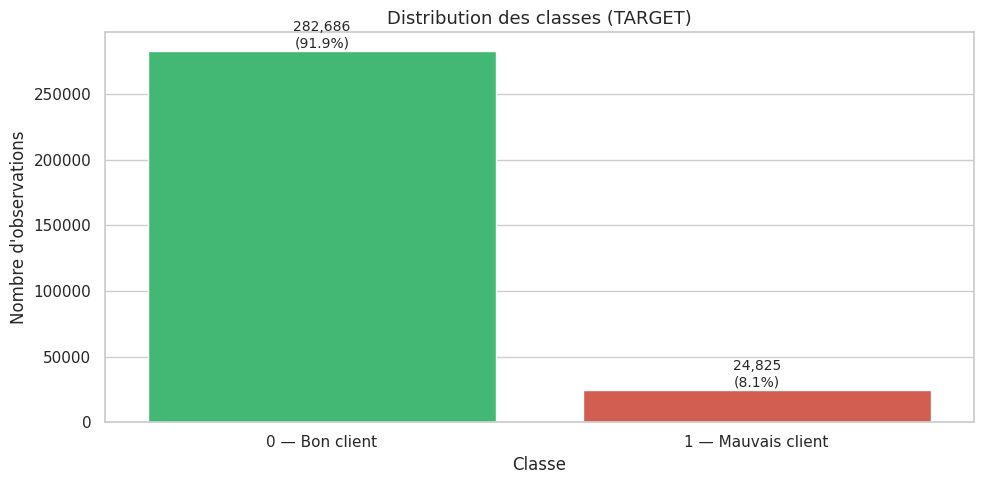

Classe 0 : 91.9% / Classe 1 : 8.1%


In [10]:
counts = df_train["TARGET"].value_counts().sort_index()
pcts = df_train["TARGET"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=counts.index, y=counts.values, palette=["#2ecc71", "#e74c3c"], ax=ax)
ax.set_title("Distribution des classes (TARGET)", fontsize=13)
ax.set_xlabel("Classe")
ax.set_ylabel("Nombre d'observations")
ax.set_xticks([0, 1])
ax.set_xticklabels(["0 — Bon client", "1 — Mauvais client"])
for bar, (cls, n, p) in zip(ax.patches, zip(counts.index, counts.values, pcts.values)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{n:,}\n({p:.1f}%)", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

print(f"Classe 0 : {pcts[0]:.1f}% / Classe 1 : {pcts[1]:.1f}%")

## 4.2 — Split stratifié

In [ ]:
X = df_train.drop(columns=["TARGET", "SK_ID_CURR"])
y = df_train["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shapes :")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")

print("\nProportion de classe 1 (vérification stratification) :")
print(f"  y_train : {y_train.mean():.4f} ({y_train.mean() * 100:.2f}%)")
print(f"  y_test  : {y_test.mean():.4f} ({y_test.mean() * 100:.2f}%)")

## 4.3 — Gestion du déséquilibre (SMOTE)

In [13]:
print("Avant SMOTE :")
print(f"  X_train shape     : {X_train.shape}")
print(f"  Proportion classe 1 : {y_train.mean():.4f} ({y_train.mean() * 100:.2f}%)")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAprès SMOTE :")
print(f"  X_train_sm shape    : {X_train_sm.shape}")
print(f"  Proportion classe 1 : {y_train_sm.mean():.4f} ({y_train_sm.mean() * 100:.2f}%)")

print("\n⚠️  X_test reste intact — jamais de SMOTE sur le test")

Avant SMOTE :
  X_train shape     : (246008, 208)
  Proportion classe 1 : 0.0807 (8.07%)

Après SMOTE :
  X_train_sm shape    : (452296, 208)
  Proportion classe 1 : 0.5000 (50.00%)

⚠️  X_test reste intact — jamais de SMOTE sur le test


## 5.1 Baseline — Logistic Regression

**Objectif** : Entraîner une Logistic Regression comme modèle de référence (baseline).  
On utilise `class_weight='balanced'` pour gérer le déséquilibre résiduel.  
Validation croisée StratifiedKFold (5 folds). Tracking MLflow complet.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
import mlflow
import mlflow.sklearn

model_lr = LogisticRegression(solver="saga", max_iter=1000, class_weight="balanced", random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with mlflow.start_run(run_name="logistic_regression_baseline"):
    mlflow.log_param("solver", "saga")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("class_weight", "balanced")

    scores = cross_val_score(model_lr, X_train_sm, y_train_sm, cv=cv, scoring="roc_auc", n_jobs=-1)

    auc_mean = scores.mean()
    auc_std  = scores.std()

    mlflow.log_metric("auc_roc_mean", auc_mean)
    mlflow.log_metric("auc_roc_std",  auc_std)

    print(f"AUC-ROC par fold : {[round(s, 4) for s in scores]}")
    print(f"AUC-ROC moyen    : {auc_mean:.4f} ± {auc_std:.4f}")

/home/bdb/Bureau/P6/Initiez-vous-au-MLOps/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/bdb/Bureau/P6/Initiez-vous-au-MLOps/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/bdb/Bureau/P6/Initiez-vous-au-MLOps/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/bdb/Bureau/P6/Initiez-vous-au-MLOps/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/bdb/Bureau/P6/Initiez-vous-au-MLOps/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reac

AUC-ROC par fold : [np.float64(0.6127), np.float64(0.6109), np.float64(0.609), np.float64(0.6105), np.float64(0.6071)]
AUC-ROC moyen    : 0.6100 ± 0.0019


## 5.2 Random Forest

**Objectif** : Entraîner un Random Forest.  
Comparaison avec la baseline Logistic Regression.  
Validation croisée StratifiedKFold (5 folds). Tracking MLflow complet.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with mlflow.start_run(run_name="random_forest_baseline"):
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("class_weight", "balanced")

    scores = cross_val_score(model_rf, X_train_sm, y_train_sm, cv=cv, scoring="roc_auc", n_jobs=-1)

    auc_mean = scores.mean()
    auc_std  = scores.std()

    mlflow.log_metric("auc_roc_mean", auc_mean)
    mlflow.log_metric("auc_roc_std",  auc_std)

    print(f"AUC-ROC par fold : {[round(s, 4) for s in scores]}")
    print(f"AUC-ROC moyen    : {auc_mean:.4f} ± {auc_std:.4f}")

AUC-ROC par fold : [np.float64(0.9827), np.float64(0.9824), np.float64(0.9819), np.float64(0.9823), np.float64(0.9826)]
AUC-ROC moyen    : 0.9824 ± 0.0003


In [18]:
from sklearn.metrics import roc_auc_score

# Entraînement sur l'ensemble SMOTE complet
model_rf.fit(X_train_sm, y_train_sm)

# Évaluation sur le test set (jamais augmenté)
y_proba_test = model_rf.predict_proba(X_test)[:, 1]
auc_roc_test = roc_auc_score(y_test, y_proba_test)

print(f"AUC-ROC test : {auc_roc_test:.4f}")

# Log dans le run MLflow "random_forest_baseline" existant
runs = mlflow.search_runs(
    filter_string='tags.mlflow.runName = "random_forest_baseline"',
    order_by=["start_time DESC"]
)
run_id = runs.iloc[0]["run_id"]

with mlflow.start_run(run_id=run_id):
    mlflow.log_metric("auc_roc_test", auc_roc_test)

AUC-ROC test : 0.7075
